In [1]:
import pandas as pd

df = pd.read_parquet("hf://datasets/ade-benchmark-corpus/ade_corpus_v2/Ade_corpus_v2_classification/train-00000-of-00001.parquet")

Final2

In [2]:
df = df.drop_duplicates().dropna()
# ----------------------------
# Imports
# ----------------------------
import os
import random
import re
import string
import numpy as np
import pandas as pd
import torch
from collections import Counter
from nltk.corpus import stopwords, words
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, average_precision_score, matthews_corrcoef
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ----------------------------
# NLTK resources
# ----------------------------
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')

stop_words = set(stopwords.words('english'))
english_words = set(words.words())

# ----------------------------
# Preprocessing
# ----------------------------
import re
import string
from nltk.tokenize import word_tokenize

def preprocess_clinical(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r'(\d)(mg|ml|mcg|g)\b', r'\1 \2', text, flags=re.I)

    text = re.sub(r'(\d+)\s*-\s*(\d+)', r'\1 to \2', text)

    allowed_punct = '.,;:%()-/'
    text = ''.join([c for c in text if c.isalnum() or c.isspace() or c in allowed_punct])

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

df['Cleantext'] = df['text'].apply(preprocess_clinical)


# ----------------------------
# Train/Val/Test split
# ----------------------------
X = df['Cleantext']
Y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.2, random_state=seed, stratify=Y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samgh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samgh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\samgh\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:

# ----------------------------
# Tokenizer
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained('distilbert/distilbert-base-uncased')
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=200)
valid_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=200)
test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=200)

# ----------------------------
# Dataset class
# ----------------------------
class DATALOADER(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = DATALOADER(train_encodings, list(y_train))
valid_dataset = DATALOADER(valid_encodings, list(y_val))
test_dataset  = DATALOADER(test_encodings, list(y_test))

# ----------------------------
# Model configuration
# ----------------------------
id2label = {0: 'Non_ADE', 1: 'ADE'}
label2id = {'Non_ADE': 0, 'ADE': 1}

config = AutoConfig.from_pretrained("distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id)
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", config=config).to(device)

# ----------------------------
# Class weights
# ----------------------------
class_counts = Counter(y_train.tolist())
total_samples = sum(class_counts.values())

# Weight = total_samples / (num_classes * samples_per_class)
num_classes = len(class_counts)
class_weights = torch.tensor(
    [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)],
    dtype=torch.float
).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# ----------------------------
# Metrics
# ----------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    mcc = matthews_corrcoef(labels, preds)
    avg_precision = average_precision_score(labels, preds)
    return {
        'accuracy': acc,
        'matthews_corrcoef': mcc,
        'avg_precision': avg_precision,
    }

# ------------from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Path to the saved model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import os

model_path = r"D:\python_project\ADE\bert-base-casedC"  # raw string to handle backslashes

# Check the folder contents
print("Files in model folder:", os.listdir(model_path))

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("✅ Model and tokenizer loaded successfully from local folder")


----------------
# Training arguments
# ----------------------------
training_args = TrainingArguments(
    output_dir='./distilbert/distilbert-base-uncased_adeC',
    num_train_epochs=10,
    fp16=torch.cuda.is_available(),
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    warmup_steps=500,
    weight_decay=0.05,
    logging_dir='./logs',
    load_best_model_at_end=True,
    logging_steps=300,
    save_steps=300,
    eval_strategy="steps",
    save_total_limit=3,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    report_to=None
)

# ----------------------------
# Weighted loss trainer
# ----------------------------
from torch.nn import CrossEntropyLoss

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ----------------------------
# Trainer initialization
# ----------------------------
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ----------------------------
# Train the model
# ----------------------------
trainer.train()



Device: cuda


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samgh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samgh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\samgh\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

D:\python_project\CudaEnv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\samgh\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distil

Class counts: Counter({0: 13299, 1: 3417})
Class weights: tensor([0.6285, 2.4460], device='cuda:0')


Step,Training Loss,Validation Loss,Accuracy,Matthews Corrcoef,Avg Precision
300,0.541000,0.333875,0.830144,0.610957,0.518098
600,0.307900,0.284397,0.895215,0.724662,0.638833
900,0.251900,0.247928,0.896651,0.731379,0.644790
1200,0.199000,0.260866,0.928230,0.788934,0.720855
1500,0.169700,0.220773,0.926794,0.792345,0.720633
1800,0.116300,0.391928,0.933493,0.797103,0.734987
2100,0.104700,0.272135,0.935885,0.816463,0.749677
2400,0.062200,0.364956,0.926794,0.793470,0.721320


TrainOutput(global_step=2400, training_loss=0.2190903345743815, metrics={'train_runtime': 391.6476, 'train_samples_per_second': 426.812, 'train_steps_per_second': 13.354, 'total_flos': 3592743529892160.0, 'train_loss': 0.2190903345743815, 'epoch': 4.589473684210526})

In [ ]:
# saving the fine tuned model & tokenizer
model_path = "ADE/distilbert/distilbert-base-uncased"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

('ADE/distilbert/distilbert-base-uncased\\tokenizer_config.json',
 'ADE/distilbert/distilbert-base-uncased\\special_tokens_map.json',
 'ADE/distilbert/distilbert-base-uncased\\vocab.txt',
 'ADE/distilbert/distilbert-base-uncased\\added_tokens.json',
 'ADE/distilbert/distilbert-base-uncased\\tokenizer.json')

In [ ]:
eval_results =trainer.evaluate(test_dataset)

# Predict on the evaluation dataset to get logits
predictions = trainer.predict(test_dataset)

In [ ]:
eval_results

{'eval_loss': 0.29922351241111755,
 'eval_accuracy': 0.915311004784689,
 'eval_matthews_corrcoef': 0.7565760582284872,
 'eval_avg_precision': 0.681965523200608,
 'eval_runtime': 2.3057,
 'eval_samples_per_second': 906.455,
 'eval_steps_per_second': 56.816,
 'epoch': 4.589473684210526}

In [ ]:
import numpy as np

# Extract true labels
true_labels = predictions.label_ids

# Extract predicted labels (argmax over logits)
preds = np.argmax(predictions.predictions, axis=1)


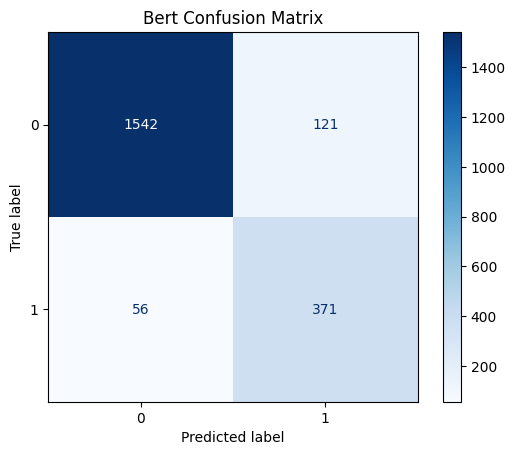

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
labels = ['0', '1']

# Compute the confusion matrix
cm = confusion_matrix(true_labels, preds)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)

plt.title('Bert Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Assuming true_labels and preds are already defined
print(classification_report(true_labels, preds, target_names=labels))


              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1663
           1       0.75      0.87      0.81       427

    accuracy                           0.92      2090
   macro avg       0.86      0.90      0.88      2090
weighted avg       0.92      0.92      0.92      2090



In [ ]:
import torch
import numpy as np

logitstrain = torch.tensor(logitstrain)  # Replace with your actual logits

# If logits are a single column (one logit per sample), apply sigmoid and compute both probabilities
if logitstrain.ndimension() == 1:  # Single logit for class 1
    probabilitiestrain = torch.sigmoid(logitstrain).unsqueeze(1)  # P(class 1)
    probabilitiestrain = torch.cat([1 - probabilitiestrain, probabilitiestrain], dim=1).numpy()  # P(class 0), P(class 1)
else:
    # If logits already have shape (n_samples, 2) (two logits for each sample), apply softmax
    probabilitiestrain = torch.nn.functional.softmax(logitstrain, dim=1).numpy()  # Shape: (n_samples, 2)


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Get predicted probabilities from model
# ----------------------------
# Evaluate on train data
train_preds = trainer.predict(train_dataset)

# Extract predicted logits and true labels
logits = train_preds.predictions
y_true = train_preds.label_ids

# Convert logits to probabilities using softmax
probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()




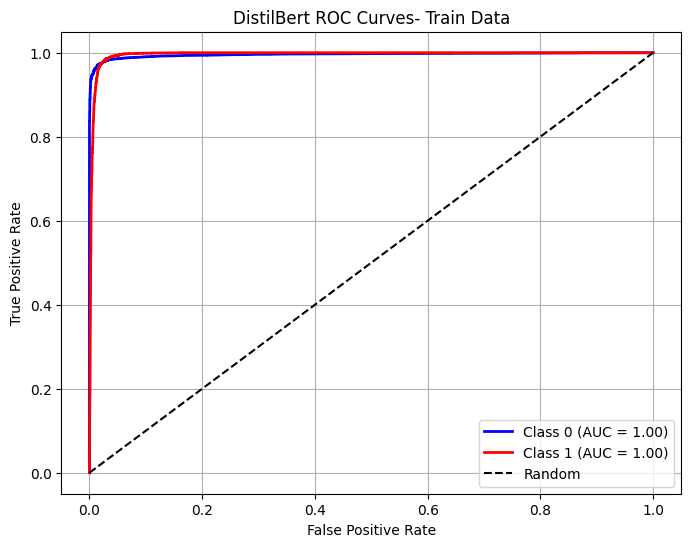

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}

# One-vs-rest approach
for i in range(2):
    # Treat class i as positive, all others as negative
    y_true_binary = (y_true == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(y_true_binary, probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ----------------------------
# Plot ROC curves
# ----------------------------
plt.figure(figsize=(8, 6))
colors = ['blue', 'red']
for i, color in zip(range(2), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DistilBert ROC Curves- Train Data')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## For Test Dataset

In [ ]:
# Evaluate on train data
test_preds = trainer.predict(test_dataset)

# Extract predicted logits and true labels
logits1 = test_preds.predictions
y_true1 = test_preds.label_ids

# Convert logits to probabilities using softmax


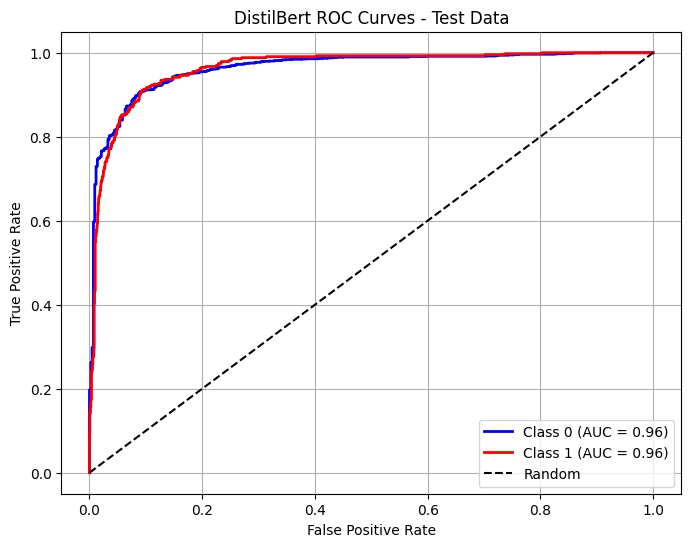

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}
probabilities = torch.nn.functional.softmax(torch.tensor(logits1), dim=1).numpy()
# One-vs-rest approach
for i in range(2):
    # Treat class i as positive, all others as negative
    y_true_binary1 = (y_true1 == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(y_true_binary1, probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ----------------------------
# Plot ROC curves
# ----------------------------
plt.figure(figsize=(8, 6))
colors = ['blue', 'red']
for i, color in zip(range(2), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DistilBert ROC Curves - Test Data')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Path to the saved model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import os

model_path = r"D:\python_project\ADE/distilbert/distilbert-base-uncased"  # raw string to handle backslashes

# Check the folder contents
print("Files in model folder:", os.listdir(model_path))

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("✅ Model and tokenizer loaded successfully from local folder")




Files in model folder: ['config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']
✅ Model and tokenizer loaded successfully from local folder


# Shap

In [8]:
import shap
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

import transformers


pred = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    return_all_scores=True,
)

Device set to use cuda:0
D:\python_project\CudaEnv\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [9]:
masker = shap.maskers.Text(tokenizer=r"\W+") # this will create a basic whitespace tokenizer
explainer= shap.Explainer(pred, masker)

In [ ]:
!pip install datasets

In [4]:
from datasets import Dataset

data_dict = {
    'text': X_test,
    'label': y_test
}

test_data = Dataset.from_dict(data_dict)

In [5]:
data = pd.DataFrame({"text": test_data["text"], "Lable": test_data["label"]})

In [ ]:
shap_values = explainer(data["text"][5:8])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
shap.plots.text(shap_values)

#Bertviz

In [ ]:
! pip install bertviz

## Non_ADE sample

In [ ]:
from transformers import DistilBertForSequenceClassification, AutoTokenizer

model1 = DistilBertForSequenceClassification.from_pretrained(
    model_path,
    attn_implementation="eager",
    output_attentions=True 
)
tokenizer = AutoTokenizer.from_pretrained(model_path)


# Sample text input
text_batch = data["text"][6:7].tolist()  # Ensure this is a list of strings

# Tokenize the input text
encoded_inputs = tokenizer(text_batch, return_tensors='pt', padding=True, truncation=True)

# Move model and inputs to the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)
encoded_inputs = {key: value.to(device) for key, value in encoded_inputs.items()}

# Run the model
outputs = model1(**encoded_inputs)

# Retrieve attention from model outputs
attentions = outputs.attentions

# Convert input ids to token strings
tokens = tokenizer.convert_ids_to_tokens(encoded_inputs['input_ids'][0])

# Display model view


In [ ]:
from bertviz import head_view
head_view(attentions, tokens)

<IPython.core.display.Javascript object>

In [ ]:
from bertviz import model_view

model_view(attentions, tokens)

<IPython.core.display.Javascript object>

## ADE Sample

In [ ]:
text_batch = data["text"][5:6].tolist()  # Ensure this is a list of strings

# Tokenize the input text
encoded_inputs = tokenizer(text_batch, return_tensors='pt', padding=True, truncation=True)

# Move model and inputs to the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)
encoded_inputs = {key: value.to(device) for key, value in encoded_inputs.items()}

# Run the model
outputs = model1(**encoded_inputs)

# Retrieve attention from model outputs
attentions = outputs.attentions

# Convert input ids to token strings
tokens = tokenizer.convert_ids_to_tokens(encoded_inputs['input_ids'][0])

# Display model view
head_view(attentions, tokens)

<IPython.core.display.Javascript object>

In [ ]:
from bertviz import model_view

model_view(attentions, tokens)

<IPython.core.display.Javascript object>

# Lime

In [ ]:
!pip install lime


## Non ADE Sample

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load model and tokenizer
model1 = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)  # Move model to GPU or CPU

# Define the predict function for LIME
def predict_probab(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
    inputs = {key: value.to(device) for key, value in inputs.items()}  # Move inputs to device
    model1.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()  # Move back to CPU for LIME

# Example of using LIME
from lime.lime_text import LimeTextExplainer



In [ ]:
explanation.show_in_notebook(text=text, labels=(1,))


In [14]:
explainer = LimeTextExplainer(class_names=["Non-ADE", "ADE"])
text = data["text"].iloc[15]  # Get a text instance
explanation = explainer.explain_instance(text, predict_probab, num_features=10)

In [19]:
text

'little likelihood significant adverse effects attributable topical minoxidil low systemic absorption .'

In [15]:
# Get explanation as a list of features with weights
explanation_list = explanation.as_list()
print(explanation_list)


[(np.str_('minoxidil'), 0.059462881858097526), (np.str_('effects'), -0.03390241227666028), (np.str_('topical'), -0.031032545735422593), (np.str_('attributable'), 0.02483772571445788), (np.str_('adverse'), 0.02165419758106882), (np.str_('likelihood'), 0.019450060106205553), (np.str_('significant'), 0.011861834694473411), (np.str_('little'), -0.011227043003811615), (np.str_('low'), 0.004853176563980253), (np.str_('systemic'), -0.001550795818863832)]


In [7]:
import matplotlib.pyplot as plt

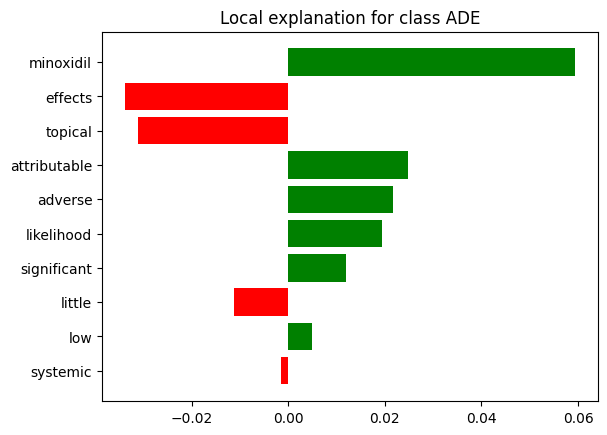

In [18]:
explanation.as_pyplot_figure()
plt.show()

## ADE Sample

In [8]:
explainer = LimeTextExplainer(class_names=["Non-ADE", "ADE"])
text = data["text"].iloc[16]  # Get a text instance
explanation = explainer.explain_instance(text, predict_probab, num_features=10)

In [ ]:
explanation.show_in_notebook(text=text, labels=(1,))


In [9]:
explanation_list = explanation.as_list()
print(explanation_list)

[(np.str_('chloramphenicol'), 0.6952219294800782), (np.str_('hypersensitivity'), 0.46124713218695956), (np.str_('patient'), -0.09508623251242189), (np.str_('following'), 0.05056560209539093), (np.str_('fever'), 0.04051482882994381), (np.str_('typhoid'), 0.03547670394268635), (np.str_('reaction'), -0.026098612737410074), (np.str_('administration'), -0.005487433178035064)]


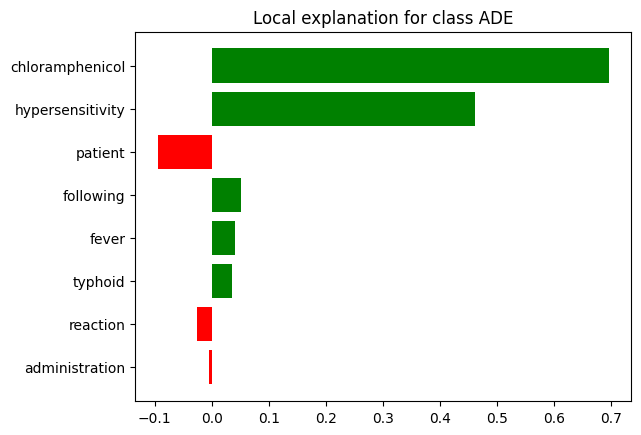

In [10]:
explanation.as_pyplot_figure()
plt.show()